In [1]:
import torch
print(torch.__version__)
import pandas as pdf
import math, random, os
from torch.utils.data import Dataset
import transformers
import numpy

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if __name__=='__main__':
    print('Using device:', DEVICE)

print(os.sys.path)

2.9.0+cu130
Using device: cuda
['/home/jefferyfan/anaconda3/envs/exp/lib/python311.zip', '/home/jefferyfan/anaconda3/envs/exp/lib/python3.11', '/home/jefferyfan/anaconda3/envs/exp/lib/python3.11/lib-dynload', '', '/home/jefferyfan/anaconda3/envs/exp/lib/python3.11/site-packages']


In [2]:
from transformers import AutoVideoProcessor, AutoModel
from huggingface_hub.utils import enable_progress_bars

enable_progress_bars()

hf_repo = "facebook/vjepa2-vitl-fpc64-256"

# The following calls should now show a progress bar in your console/environment
model = AutoModel.from_pretrained(hf_repo)
processor = AutoVideoProcessor.from_pretrained(hf_repo)

In [ ]:
import torch
from torchcodec.decoders import VideoDecoder
import numpy as np

video_url = "../room.mp4"
vr = VideoDecoder(video_url)
# frame_idx = np.arange(0, 0+64) # for output.mp4
frame_idx = np.arange(0, 64) # for room.mp4 choosing some frames. here, you can define more complex sampling strategy
frame2_idx = frame_idx + 4
video = vr.get_frames_at(indices=frame_idx).data
video2 = vr.get_frames_at(indices=frame2_idx).data

video = processor(video, return_tensors="pt").to(model.device)
video2 = processor(video2, return_tensors="pt").to(model.device)
with torch.no_grad():
    video_embeddings = model.get_vision_features(**video)
    video2_embeddings = model.get_vision_features(**video2)


torch.Size([1, 64, 128, 1024])


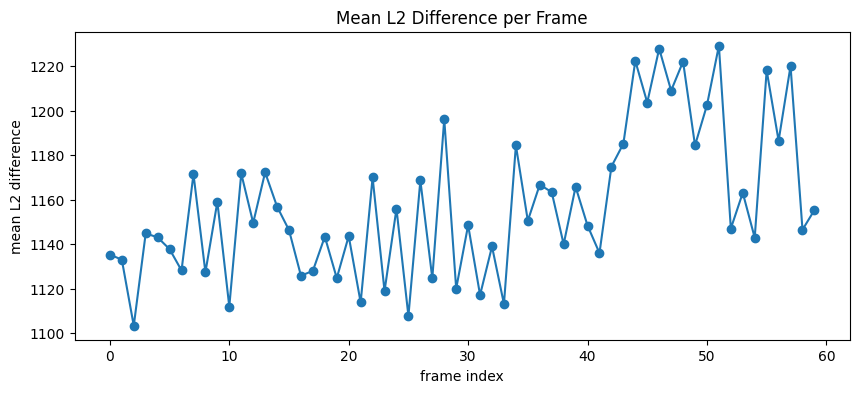

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Reshape video_embeddings to (batch_size, frames, patches_per_frame, feature_dim)
num_frames = 64
patches_per_frame = video_embeddings.shape[1] // num_frames
batch_size = video_embeddings.shape[0]
feature_dim = video_embeddings.shape[2]

# reshape embeddings to (batch, frames, patches_per_frame, feature_dim)
ve = video_embeddings.reshape(batch_size, num_frames, patches_per_frame, feature_dim)
v2e = video2_embeddings.reshape(batch_size, num_frames, patches_per_frame, feature_dim)

print(ve.shape)

# ve[2:] (frames 2:64) matched to v2e[:-2] (frames 0:62)
diff = ve[:, 4:] - v2e[:, :-4]
# Calculate the L2 norm (Euclidean distance) per frame across patches and feature_dim, mean over batch
# Calculate the L2 norm (Euclidean distance) per frame across patches and feature_dim, mean over batch
# diff shape: (batch, frames=62, patches_per_frame, feature_dim)
l2_per_frame = np.mean(np.linalg.norm(diff.cpu().numpy(), axis=(2, 3)), axis=0)  # mean over batch, patches, features

plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(l2_per_frame)), l2_per_frame, marker='o')
plt.xlabel('frame index')
plt.ylabel('mean L2 difference')
plt.title('Mean L2 Difference per Frame')
plt.show()
